# LJ Pair MD Notebook

Uses the neighbor-list path in `md.py` to run a pairwise Lennard-Jones test with:
1. a padded fixed-width neighbor list
2. periodic boundary conditions
3. a full-configuration pair potential differentiated with `jax.value_and_grad`

In [12]:
import sys
sys.path.insert(0, '.')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from ase.build import bulk

from md import MD, Timer
from potentials import get_potential
from trajectory_io import view_trajectory_ngl, write_ovito_dump
from plotting import plot_xy, plot_xy_multiple

## 1. Define The Pair Potential

Here the potential follows the full-configuration interface
`potential(positions, neighbor_list, box)`.
Internally it calls `pair_distances(...)` from `neighbor_list.py`.

In [2]:
sigma = 1.0
eps = 1.0
r_skin = 0.3 * sigma
temperature = 1.0
density = 0.844
a = (4/density)**(1/3)
fcc_lattice_constant = a
fcc_repetitions = (6, 6, 6)
max_neighbors = 128


## 2. Initial Conditions

In [3]:
dt = 0.004
m  = 1.0

key = jax.random.PRNGKey(42)
key_v = key

atoms = bulk('Cu', 'fcc', a=fcc_lattice_constant, cubic=True).repeat(fcc_repetitions)
r0 = jnp.array(atoms.get_positions(), dtype=jnp.float32)
box = jnp.array(atoms.cell.lengths(), dtype=jnp.float32)
N = len(atoms)
r_cut = 2.5 * sigma
potential = get_potential("lennard_jones", eps=eps, sigma=sigma, r_cut=r_cut, shift=True)
v0 = MD.initialize_velocities(N, temperature=temperature, m=m, rng_key=key_v)
a0 = jnp.zeros((N, 3))

print(f"fcc repetitions: {fcc_repetitions}")
print(f"box: {box}")
print(f"N: {N}")
print(f"temperature: {temperature}")
print(f"r_cut: {r_cut:.3f}, r_skin: {r_skin:.3f}, max_neighbors: {max_neighbors}")
print(f"r0: {r0.shape}, v0: {v0.shape}, a0: {a0.shape}")

fcc repetitions: (6, 6, 6)
box: [10.078373 10.078373 10.078373]
N: 864
temperature: 1.0
r_cut: 2.500, r_skin: 0.300, max_neighbors: 128
r0: (864, 3), v0: (864, 3), a0: (864, 3)


## 3. Run 

In [4]:
sim = MD(
    r0,
    v0,
    a0,
    potential,
    dt=dt,
    m=m,
    neighbor_list_mode="many-body",
    box=box,
    r_cut=r_cut,
    r_skin=r_skin,
    neighbor_list_pbc=True,
    neighbor_list_padded=True,
    neighbor_list_max_neighbors=max_neighbors,
)

with Timer("MD run (progress mode)"):
    traj = sim.run(n_steps=5000, performance=True, chunk_size=20, progress_backend="notebook")

print(f"positions trajectory : {traj['positions'].shape}")
print(f"forces trajectory    : {traj['forces'].shape}")
print(f"temperature shape    : {traj['temperature'].shape}")
print(f"final positions      : {sim.r.shape}")

[MD run (progress mode)] elapsed: 33.8522s
positions trajectory : (5000, 864, 3)
forces trajectory    : (5000, 864, 3)
temperature shape    : (5000,)
final positions      : (864, 3)


## 4. Save & reload trajectory

In [5]:
sim.save_trajectory('trajectory')

loaded = MD.load_trajectory('trajectory.npz')
print({k: v.shape for k, v in loaded.items()})

Trajectory saved to trajectory.npz
{'positions': (5000, 864, 3), 'unwrapped_positions': (5000, 864, 3), 'velocities': (5000, 864, 3), 'accelerations': (5000, 864, 3), 'forces': (5000, 864, 3), 'potential_energy': (5000,), 'kinetic_energy': (5000,), 'temperature': (5000,)}


## 5. Analysis

### Kinetic energy

### Mean squared displacement (MSD)

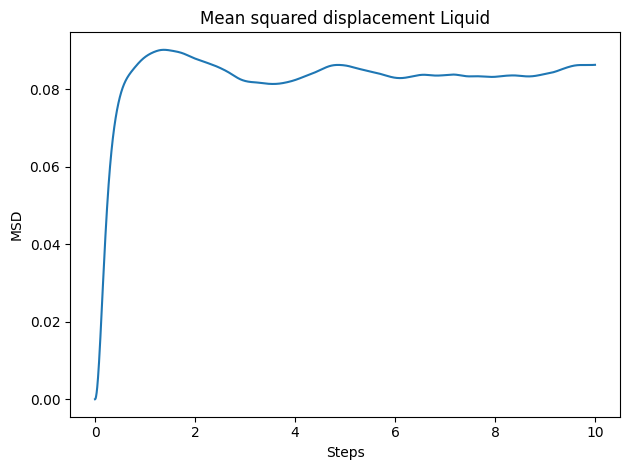

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Mean squared displacement Liquid'}, xlabel='Steps', ylabel='MSD'>,
 PosixPath('plots/tp_lj/mean_squared_displacement_liquid.png'))

In [6]:
r = traj["unwrapped_positions"]  
n_steps = len(r)
max_lag = n_steps // 2 

msd = np.zeros(max_lag)
for delta_t in range(1, max_lag):
    displacements = r[delta_t:] - r[:n_steps - delta_t]  
    squared_disp = np.sum(displacements ** 2, axis=-1)   
    msd[delta_t] = np.mean(squared_disp)                 

time = np.arange(max_lag) * dt
plot_xy(time, msd, xlabel="Steps", ylabel="MSD", title="Mean squared displacement Liquid", name="tp_lj",save=True)

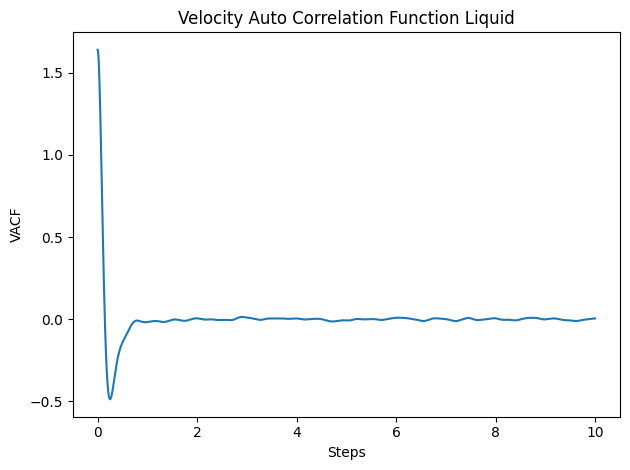

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Velocity Auto Correlation Function Liquid'}, xlabel='Steps', ylabel='VACF'>,
 PosixPath('plots/tp_lj/velocity_auto_correlation_function_liquid.png'))

In [7]:
v = traj["velocities"]  # (n_steps, N, 3)
n_steps = len(r)
max_lag = n_steps // 2 

vacf = np.zeros(max_lag)
for delta_t in range(max_lag):
    v_product = v[delta_t:] * v[:n_steps - delta_t]       # element-wise
    dot_products = np.sum(v_product, axis=-1)              # dot product over x,y,z -> (n_origins, N)
    vacf[delta_t] = np.mean(dot_products)                  # average over origins and particles

time = np.arange(max_lag) * dt
plot_xy(time, vacf, xlabel="Steps", ylabel="VACF", title="Velocity Auto Correlation Function Liquid", name="tp_lj",save=True)

### Order N Algorithm

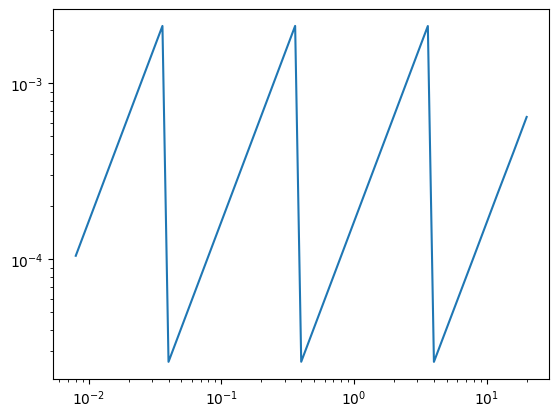

In [8]:
import numpy as np

class OrderNCorrelator:
    """
    Order-n algorithm for MSD and VACF (Frenkel & Smit, Algorithm 9).
    
    Processes one sample at a time (call add() each MD step).
    Uses hierarchical blocking with block size n and up to ibmax levels.
    At level ib, the time resolution is n^ib * dt.
    Each level stores up to n block sums. When a block of n is full,
    it's averaged and pushed to the next level.
    """

    def __init__(self, n_particles, dim=3, n=10, ibmax=20):
        self.n_particles = n_particles
        self.dim = dim
        self.n = n              # block size (number of slots per level)
        self.ibmax = ibmax      # max number of blocking levels

        # Per-level state
        self.ibl = np.zeros(ibmax, dtype=int)          # current block length at each level
        self.tel = np.zeros((ibmax, n), dtype=int)      # count of updates per (level, slot)
        self.delr2 = np.zeros((ibmax, n))               # running MSD accumulator
        # Coarse-grained velocity block sums: (level, slot, particle, dim)
        self.vxsum = np.zeros((ibmax, n, n_particles, dim))

        self.ntel = 0  # global step counter

    def add(self, v, r_unwrapped):
        """
        Call once per MD step.
        v             : (n_particles, dim) current velocities
        r_unwrapped   : (n_particles, dim) current unwrapped positions
        """
        self.ntel += 1
        n = self.n

        # Determine how many blocking levels to process this step.
        # Level ib is updated when ntel is a multiple of n^ib.
        iblm = 0
        tmp = self.ntel
        while tmp % n == 0 and iblm < self.ibmax - 1:
            iblm += 1
            tmp //= n

        # Process each level that fires this step
        for ib in range(iblm + 1):
            # Increase block length at this level
            self.ibl[ib] += 1
            inm = min(self.ibl[ib], n)  # effective number of filled slots

            for i in range(self.n_particles):
                # The "new data" entering this level:
                if ib == 0:
                    delx = v[i]              # level 0: raw velocity
                else:
                    delx = self.vxsum[ib - 1, 0, i]  # higher levels: previous level's oldest block sum

                # Update the running block sums (shift and accumulate)
                for j in range(inm - 1, 0, -1):  # iterate slots from end to 1
                    if j < n - 1:
                        # Eq. 4.4.22: accumulate into existing slot
                        self.vxsum[ib, j, i] = self.vxsum[ib, j + 1, i] + delx
                    else:
                        # Eq. 4.4.23 / 4.4.26: start new slot
                        self.vxsum[ib, j, i] = delx

                # Handle slot 0 (newest)
                if inm < n:
                    # Array not yet full: Eq. 4.4.25
                    self.vxsum[ib, 0, i] = self.vxsum[ib, 1, i] + delx if inm > 1 else delx
                else:
                    # Array full: Eq. 4.4.26
                    self.vxsum[ib, 0, i] = delx

            # Correlate: update MSD and count accumulators
            for j in range(inm):
                self.tel[ib, j] += 1
                for i in range(self.n_particles):
                    # MSD update via Eq. 4.4.24:
                    # delr2 += |v_sum(ib, inm - j, i)|^2
                    self.delr2[ib, j] += np.sum(
                        self.vxsum[ib, inm - j - 1, i] ** 2
                    )

    def get_results(self, dt):
        """
        Return (time, msd) arrays after all samples have been added.
        dt : MD timestep
        """
        n = self.n
        times = []
        msds = []

        for ib in range(self.ibmax):
            inm = min(self.ibl[ib], n)
            for j in range(1, inm):  # skip j=0 (zero lag at each level)
                if self.tel[ib, j] > 0:
                    t = (j + 1) * dt * (n ** ib)
                    msd = self.delr2[ib, j] * (dt ** 2) / (self.n_particles * self.tel[ib, j])
                    times.append(t)
                    msds.append(msd)

        # Sort by time and return
        order = np.argsort(times)
        return np.array(times)[order], np.array(msds)[order]
    

correlator = OrderNCorrelator(n_particles=N, n=10, ibmax=10)

for step in range(n_steps):
    correlator.add(v[step], r[step])

time, msd = correlator.get_results(dt=0.004)
plt.loglog(time, msd)

### Gas

In [9]:
sigma = 1.0
eps = 1.0
r_skin = 0.3 * sigma
temperature = 2.0
density = 0.055
a = (4/density)**(1/3)
fcc_lattice_constant = a
fcc_repetitions = (6, 6, 6)
max_neighbors = 128

dt = 0.004
m  = 1.0

key = jax.random.PRNGKey(42)
key_v = key

atoms = bulk('Cu', 'fcc', a=fcc_lattice_constant, cubic=True).repeat(fcc_repetitions)
r0 = jnp.array(atoms.get_positions(), dtype=jnp.float32)
box = jnp.array(atoms.cell.lengths(), dtype=jnp.float32)
N = len(atoms)
r_cut = 2.5 * sigma
potential = get_potential("lennard_jones", eps=eps, sigma=sigma, r_cut=r_cut, shift=True)
v0 = MD.initialize_velocities(N, temperature=temperature, m=m, rng_key=key_v)
a0 = jnp.zeros((N, 3))

print(f"fcc repetitions: {fcc_repetitions}")
print(f"box: {box}")
print(f"N: {N}")
print(f"temperature: {temperature}")
print(f"r_cut: {r_cut:.3f}, r_skin: {r_skin:.3f}, max_neighbors: {max_neighbors}")
print(f"r0: {r0.shape}, v0: {v0.shape}, a0: {a0.shape}")


fcc repetitions: (6, 6, 6)
box: [25.044767 25.044767 25.044767]
N: 864
temperature: 2.0
r_cut: 2.500, r_skin: 0.300, max_neighbors: 128
r0: (864, 3), v0: (864, 3), a0: (864, 3)


In [10]:
sim = MD(
    r0,
    v0,
    a0,
    potential,
    dt=dt,
    m=m,
    neighbor_list_mode="many-body",
    box=box,
    r_cut=r_cut,
    r_skin=r_skin,
    neighbor_list_pbc=True,
    neighbor_list_padded=True,
    neighbor_list_max_neighbors=max_neighbors,
)

with Timer("MD run (progress mode)"):
    traj = sim.run(n_steps=5000, performance=True, chunk_size=20, progress_backend="notebook")

print(f"positions trajectory : {traj['positions'].shape}")
print(f"forces trajectory    : {traj['forces'].shape}")
print(f"temperature shape    : {traj['temperature'].shape}")
print(f"final positions      : {sim.r.shape}")

sim.save_trajectory('trajectory')

loaded = MD.load_trajectory('trajectory.npz')
print({k: v.shape for k, v in loaded.items()})

[MD run (progress mode)] elapsed: 38.4109s
positions trajectory : (5000, 864, 3)
forces trajectory    : (5000, 864, 3)
temperature shape    : (5000,)
final positions      : (864, 3)
Trajectory saved to trajectory.npz
{'positions': (5000, 864, 3), 'unwrapped_positions': (5000, 864, 3), 'velocities': (5000, 864, 3), 'accelerations': (5000, 864, 3), 'forces': (5000, 864, 3), 'potential_energy': (5000,), 'kinetic_energy': (5000,), 'temperature': (5000,)}


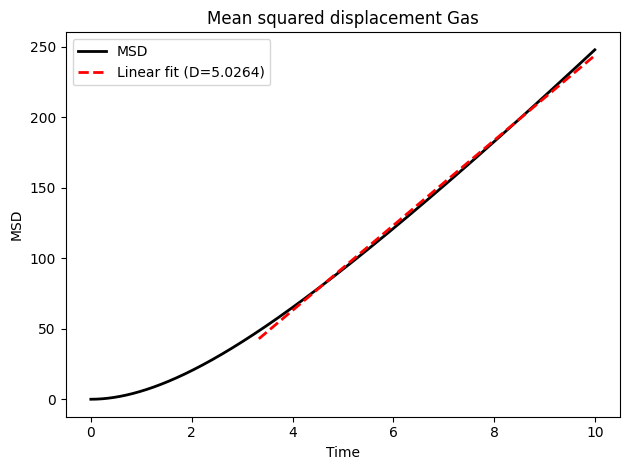

Tail-fit slope: 30.158120
Estimated diffusion coefficient from MSD: 5.026353


In [13]:
from scipy.optimize import curve_fit

r = traj["unwrapped_positions"]
n_steps = len(r)
max_lag = n_steps // 2

msd = np.zeros(max_lag)
for delta_t in range(1, max_lag):
    displacements = r[delta_t:] - r[:n_steps - delta_t]
    squared_disp = np.sum(displacements ** 2, axis=-1)
    msd[delta_t] = np.mean(squared_disp)

time = np.arange(max_lag) * dt
fit_start = max_lag // 3
fit_time = time[fit_start:]
fit_msd = msd[fit_start:]

def linear_fn(t, m, b):
    return m * t + b

params, _ = curve_fit(linear_fn, fit_time, fit_msd)
msd_fit = linear_fn(fit_time, *params)
d_msd = params[0] / 6.0

plot_xy_multiple(
    [
        {"x": time, "y": msd, "label": "MSD", "color": "black", "linewidth": 2},
        {"x": fit_time, "y": msd_fit, "label": f"Linear fit (D={d_msd:.4f})", "color": "red", "linestyle": "--", "linewidth": 2},
    ],
    xlabel="Time",
    ylabel="MSD",
    title="Mean squared displacement Gas",
    name="tp_lj",
    legend=True,
    save=True,
)

print(f"Tail-fit slope: {params[0]:.6f}")
print(f"Estimated diffusion coefficient from MSD: {d_msd:.6f}")


/var/folders/tw/mv_ty3y54bs2c7dlyfpj881c0000gn/T/ipykernel_73132/990332201.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  vacf_integral, vacf_integral_err = quad(vacf_interp, float(time[0]), float(time[-1]))


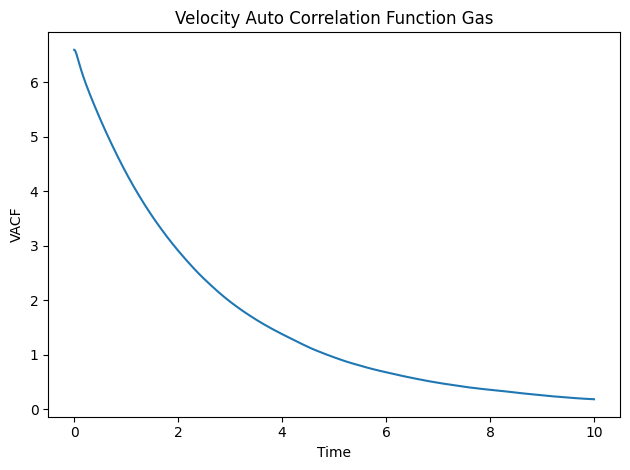

Integrated VACF: 16.463581 +/- 2.10e-06
Estimated diffusion coefficient from VACF: 5.487860


In [14]:
from scipy.integrate import quad

v = traj["velocities"]
n_steps = len(r)
max_lag = n_steps // 2

vacf = np.zeros(max_lag)
for delta_t in range(max_lag):
    v_product = v[delta_t:] * v[:n_steps - delta_t]
    dot_products = np.sum(v_product, axis=-1)
    vacf[delta_t] = np.mean(dot_products)

time = np.arange(max_lag) * dt

def vacf_interp(t):
    return np.interp(t, time, vacf)

vacf_integral, vacf_integral_err = quad(vacf_interp, float(time[0]), float(time[-1]))
d_vacf = vacf_integral / 3.0

plot_xy(time, vacf, xlabel="Time", ylabel="VACF", title="Velocity Auto Correlation Function Gas", name="tp_lj", save=True)

print(f"Integrated VACF: {vacf_integral:.6f} +/- {vacf_integral_err:.2e}")
print(f"Estimated diffusion coefficient from VACF: {d_vacf:.6f}")
